## Fórmula

A cada divisão, o algoritmo escolhe o atributo que melhor separa as classes.

Única variável exploratória.


## Características

Modelo interpretável: pode ser visualizado como um fluxograma.

Não exige normalização dos dados.

Pode capturar relações não lineares.

Propenso a overfitting se não for limitado (ex.: max_depth).

Funciona para classificação e regressão.

## Hiperparâmetro

max_depth
Controla o tamanho máximo da árvore, reduzindo risco de overfitting.

## Funcionamento

1. Seleciona o atributo que melhor separa os dados (maior ganho de informação).

2. Divide o dataset em ramos de acordo com esse atributo.

3. Repete o processo até atingir um critério de parada ou formar folhas puras.


## Decision Tree para Classificação

Accuracy: 0.92


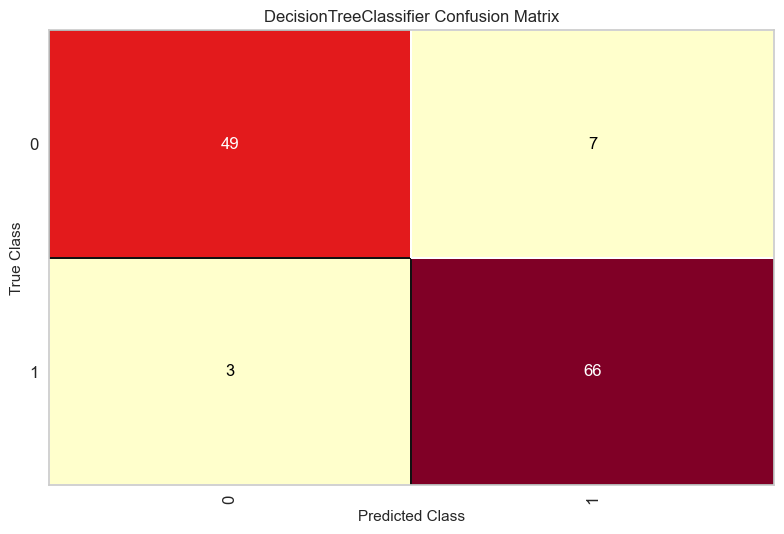

<Axes: title={'center': 'DecisionTreeClassifier Confusion Matrix'}, xlabel='Predicted Class', ylabel='True Class'>

In [1]:
# ==== Gerando base de dados sintética ====
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=500,
    n_features=4,
    n_informative=3,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

# ==== Separação treino/teste ====
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

# ==== Modelo: Decision Tree ====
from sklearn.tree import DecisionTreeClassifier

modelo = DecisionTreeClassifier(
    criterion="gini",
    max_depth=None,
    random_state=42
)

modelo.fit(X_train, y_train)

# ==== Predições ====
y_pred = modelo.predict(X_test)

# ==== Métrica: Accuracy ====
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# ==== Confusion Matrix ====
from yellowbrick.classifier import ConfusionMatrix

cm = ConfusionMatrix(modelo)
cm.fit(X_train, y_train)
cm.score(X_test, y_test)
cm.show()


## Decision Tree para Regressão

In [8]:
# ==== Gerando base de dados sintética para regressão ====
from sklearn.datasets import make_regression

X, y = make_regression(
    n_samples=500,
    n_features=4,
    noise=10,
    random_state=42
)

# ==== Separação treino/teste ====
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

# ==== Modelo: Decision Tree Regressor ====
from sklearn.tree import DecisionTreeRegressor

modelo = DecisionTreeRegressor(
    criterion="squared_error",
    max_depth=5,
    random_state=42
)

modelo.fit(X_train, y_train)

# ==== Scores (R²) ====
from sklearn.metrics import r2_score

score_treino = r2_score(y_train, modelo.predict(X_train))
score_teste  = r2_score(y_test, modelo.predict(X_test))

print("Score Treino (R²):", score_treino)
print("Score Teste  (R²):", score_teste)

# ==== Predições ====
y_pred = modelo.predict(X_test)

# ==== Métricas: MAE e MSE ====
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("\nMAE:", mae)
print("MSE:", mse)


Score Treino (R²): 0.907525121830114
Score Teste  (R²): 0.8073633301141535

MAE: 19.658384582925876
MSE: 586.0644324185699
